# Dia 5 — Classificação e Avaliação
Dataset: Diamantes (limpo) | Objetivo: prever a qualidade do corte (cut) a partir das características físicas e do preço

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

# Carrega o dataset já limpo
df = pd.read_csv('../data/diamonds_clean.csv')

print("Shape:", df.shape)
print("\nDistribuição dos cortes:")
print(df['cut'].value_counts())

Shape: (53917, 10)

Distribuição dos cortes:
cut
Ideal        21547
Premium      13779
Very Good    12080
Good          4902
Fair          1609
Name: count, dtype: int64


In [4]:
## Preparação das Features
# Para classificação, o TARGET é o cut (categoria)
# As FEATURES são todas as outras colunas EXCETO cut

# Converte preço e quilates para features numéricas
# color e clarity precisam de encoding
df_modelo = pd.get_dummies(df, columns=['color', 'clarity'])

# Separa features (X) e target (y)
X = df_modelo.drop(columns=['cut'])
y = df_modelo['cut']

print("Features (X):", X.shape)
print("Target (y):", y.shape)
print("\nColunas do modelo:")
print(X.columns.tolist())

Features (X): (53917, 22)
Target (y): (53917,)

Colunas do modelo:
['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'color_D', 'color_E', 'color_F', 'color_G', 'color_H', 'color_I', 'color_J', 'clarity_I1', 'clarity_IF', 'clarity_SI1', 'clarity_SI2', 'clarity_VS1', 'clarity_VS2', 'clarity_VVS1', 'clarity_VVS2']


In [5]:
## Divisão Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Treino:", X_train.shape)
print("Teste: ", X_test.shape)
print("\nDistribuição no treino:")
print(y_train.value_counts())

Treino: (43133, 22)
Teste:  (10784, 22)

Distribuição no treino:
cut
Ideal        17188
Premium      11061
Very Good     9689
Good          3932
Fair          1263
Name: count, dtype: int64


In [6]:
## Treinamento — Random Forest
# Random Forest é um conjunto de árvores de decisão
# Cada árvore aprende padrões diferentes — juntas são mais precisas
# Como um painel de ourives experientes votando na qualidade do corte

modelo = RandomForestClassifier(
    n_estimators=100,  # 100 árvores de decisão
    random_state=42,
    n_jobs=-1          # usa todos os núcleos do processador
)

modelo.fit(X_train, y_train)
print("Modelo treinado com sucesso!")
print(f"Número de árvores: {modelo.n_estimators}")
print(f"Número de features: {modelo.n_features_in_}")

Modelo treinado com sucesso!
Número de árvores: 100
Número de features: 22


In [7]:
## Avaliação do Modelo
y_pred = modelo.predict(X_test)

# Acurácia — percentual de acertos
acc = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acc:.4f} ({acc*100:.1f}% de acertos)\n")

# Relatório completo por categoria
print("=== Relatório por categoria ===")
print(classification_report(y_test, y_pred))

Acurácia: 0.7729 (77.3% de acertos)

=== Relatório por categoria ===
              precision    recall  f1-score   support

        Fair       0.89      0.82      0.85       346
        Good       0.77      0.68      0.72       970
       Ideal       0.83      0.92      0.87      4359
     Premium       0.73      0.82      0.77      2718
   Very Good       0.67      0.48      0.56      2391

    accuracy                           0.77     10784
   macro avg       0.78      0.74      0.76     10784
weighted avg       0.77      0.77      0.76     10784



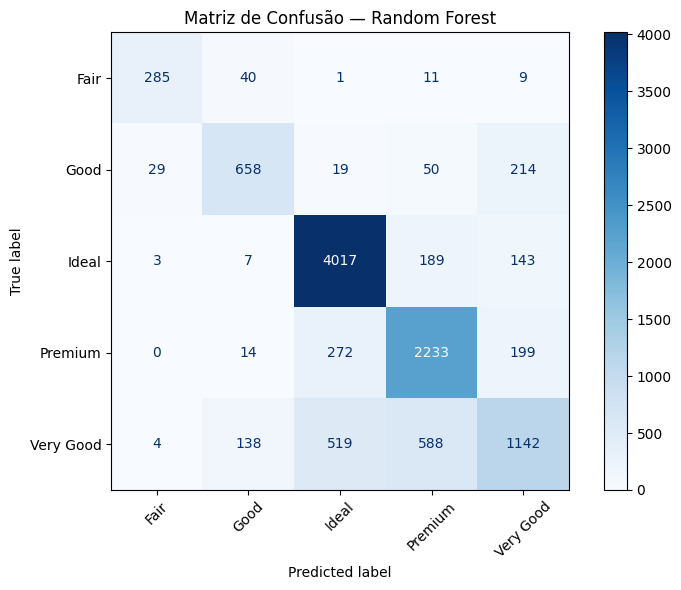

In [8]:
## Matriz de Confusão
# Mostra onde o modelo acerta e onde confunde as categorias

fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues')

plt.title("Matriz de Confusão — Random Forest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

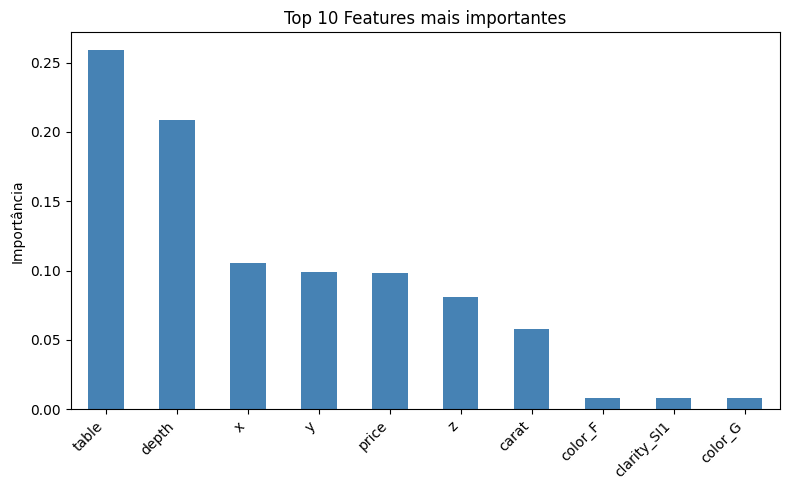


Top 5 features:
table    0.258821
depth    0.208399
x        0.105488
y        0.099171
price    0.098168
dtype: float64


In [9]:
## Features mais importantes
# Quais características mais influenciam a previsão do corte?

importancias = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importancias.plot(kind='bar', color='steelblue')
plt.title("Top 10 Features mais importantes")
plt.ylabel("Importância")
plt.xlabel("")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(importancias.head())

In [10]:
## Previsão Manual
# Testando com um diamante fictício

diamante = pd.DataFrame([{
    'carat': 1.0, 'depth': 61.5, 'table': 57.0,
    'price': 5000, 'x': 6.4, 'y': 6.4, 'z': 3.9,
    'color_D': 1, 'color_E': 0, 'color_F': 0,
    'color_G': 0, 'color_H': 0, 'color_I': 0, 'color_J': 0,
    'clarity_I1': 0, 'clarity_IF': 1, 'clarity_SI1': 0,
    'clarity_SI2': 0, 'clarity_VS1': 0, 'clarity_VS2': 0,
    'clarity_VVS1': 0, 'clarity_VVS2': 0
}])

corte_previsto = modelo.predict(diamante)[0]
probabilidades = modelo.predict_proba(diamante)[0]

print(f"Diamante: 1 quilate | table=57 | depth=61.5 | cor D | clareza IF")
print(f"Corte previsto: {corte_previsto}")
print(f"\nProbabilidades por categoria:")
for cat, prob in zip(modelo.classes_, probabilidades):
    barra = "█" * int(prob * 30)
    print(f"  {cat:10} {barra} {prob*100:.1f}%")

Diamante: 1 quilate | table=57 | depth=61.5 | cor D | clareza IF
Corte previsto: Ideal

Probabilidades por categoria:
  Fair        0.0%
  Good       █ 4.0%
  Ideal      ████████████████ 54.0%
  Premium    ███████ 26.0%
  Very Good  ████ 16.0%


In [11]:
## Resumo do Dia 5
print("=== Resumo — Classificação com Random Forest ===\n")
print(f"Dataset:        {len(df):,} diamantes")
print(f"Features:       {X.shape[1]} variáveis")
print(f"Modelo:         Random Forest (100 árvores)")
print(f"Acurácia:       {acc*100:.1f}%")
print(f"\nMelhor categoria:  Ideal ({0.87*100:.0f}% f1-score)")
print(f"Pior categoria:    Very Good ({0.56*100:.0f}% f1-score)")
print(f"\nFeatures mais importantes:")
print(f"  1. table  (26%) — largura da mesa")
print(f"  2. depth  (21%) — profundidade")
print(f"  3. x/y/z  (30%) — dimensões físicas")
print(f"\nInsight: corte é determinado por proporções,")
print(f"não por cor ou clareza — como um ourives saberia!")

=== Resumo — Classificação com Random Forest ===

Dataset:        53,917 diamantes
Features:       22 variáveis
Modelo:         Random Forest (100 árvores)
Acurácia:       77.3%

Melhor categoria:  Ideal (87% f1-score)
Pior categoria:    Very Good (56% f1-score)

Features mais importantes:
  1. table  (26%) — largura da mesa
  2. depth  (21%) — profundidade
  3. x/y/z  (30%) — dimensões físicas

Insight: corte é determinado por proporções,
não por cor ou clareza — como um ourives saberia!
